## EDA part

1.Find the shape of the data,data type of individual columns

2.Check the presence of missing values

3.Descriptive stats of numerical columns

4.Distribution of categorical columns

5.Explore correlation through pair plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [42]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [44]:
# Find the shape of the data, data type of individual columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset has 1338 instances with 7 attributes. 2 integer type, 2 float type and 3 object type.

In [47]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [49]:
# Check the presence of missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

We can see there are no null values in this dataset

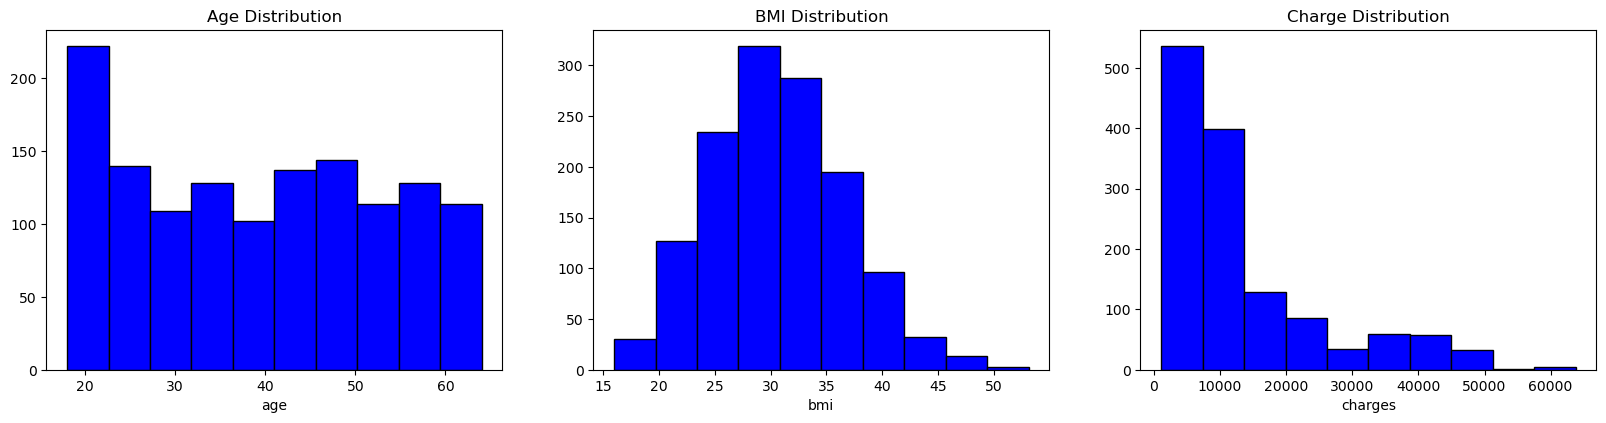

In [52]:
# Descriptive stats of numerical columns
plt.figure(figsize= (20,15))

plt.subplot(3,3,1)
plt.hist(df.age, color='blue', edgecolor = 'black')
plt.xlabel('age')
plt.title('Age Distribution')

plt.subplot(3,3,2)
plt.hist(df.bmi, color='blue', edgecolor = 'black')
plt.xlabel('bmi')
plt.title('BMI Distribution')

plt.subplot(3,3,3)
plt.hist(df.charges, color='blue', edgecolor = 'black')
plt.xlabel('charges')
plt.title('Charge Distribution')

plt.show()

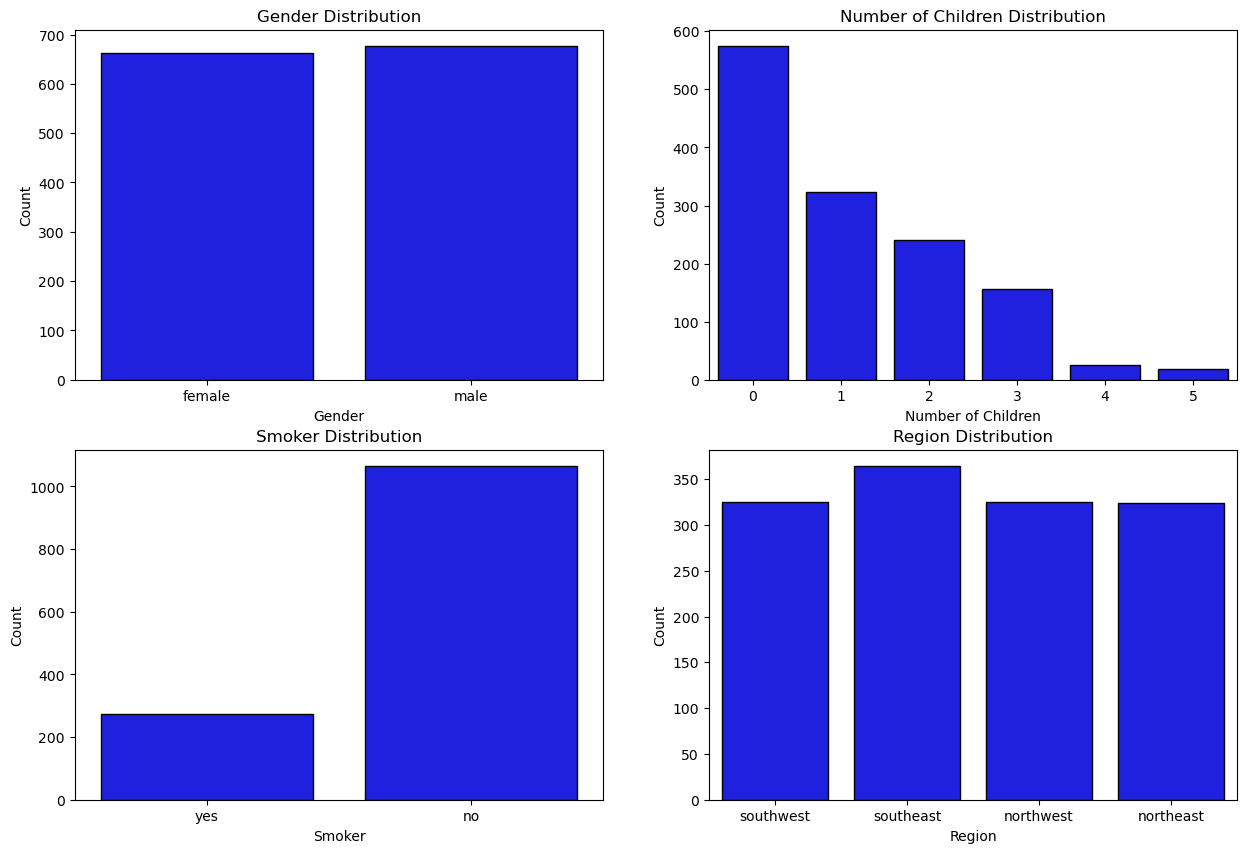

In [53]:
# Distribution of categorical columns
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='sex',color='blue',edgecolor = 'black')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='children',color='blue',edgecolor = 'black')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.title('Number of Children Distribution')

plt.subplot(2, 2, 3)
sns.countplot(data=df, x='smoker',color='blue',edgecolor = 'black')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.title('Smoker Distribution')

plt.subplot(2, 2, 4)
sns.countplot(data=df, x='region',color='blue',edgecolor = 'black')
plt.xlabel('Region')
plt.ylabel('Count')
plt.title('Region Distribution')

plt.show()

Then we do the label encoding.
Here is the mapping of the categorical variables to numerical values:

- **Sex (`sex`)**:
  - `female`: 0
  - `male`: 1

- **Smoker Status (`smoker`)**:
  - `yes`: 0
  - `no`: 1

- **Region (`region`)**:
  - `southwest`: 0
  - `southeast`: 1
  - `northwest`: 2
  - `northeast`: 3


In [56]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'yes': 0, 'no': 1})
df['region'] = df['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,0,0,16884.92400
1,18,1,33.770,1,1,1,1725.55230
2,28,1,33.000,3,1,1,4449.46200
3,33,1,22.705,0,1,2,21984.47061
4,32,1,28.880,0,1,2,3866.85520


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


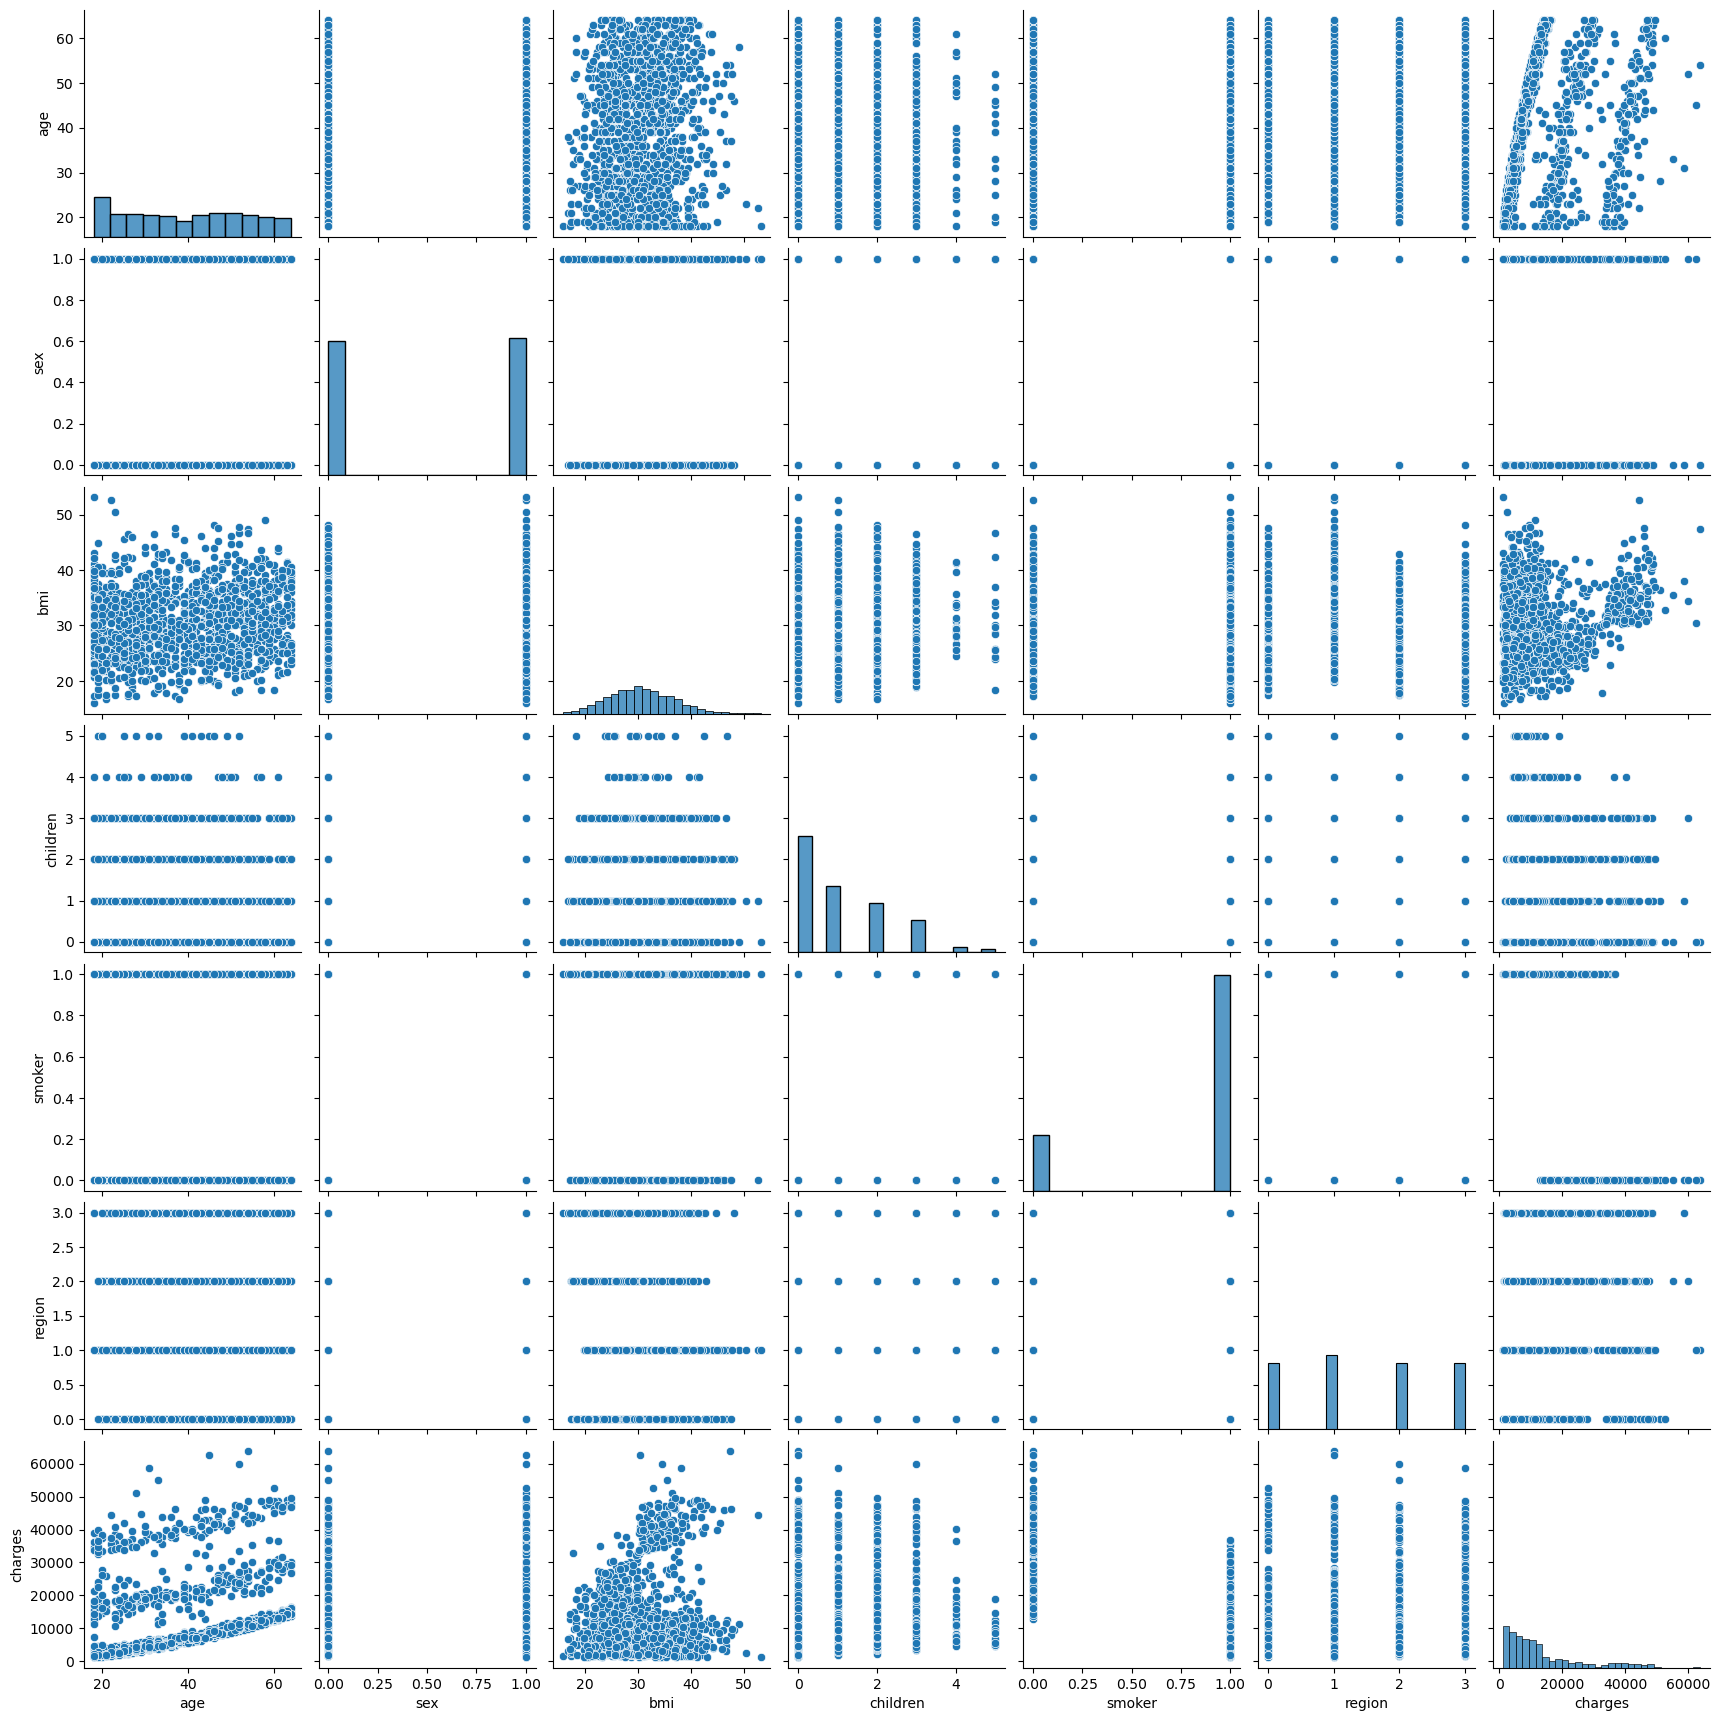

In [61]:
sns.pairplot(df)  #pairplot
plt.show()

We can say that there is some relation between age and charges, as the age increases charges also increases.

Looks like smokers claimed more money than non-smokers.

Then we use "smoke" as hue to visualize more directly.

<Axes: xlabel='age', ylabel='charges'>

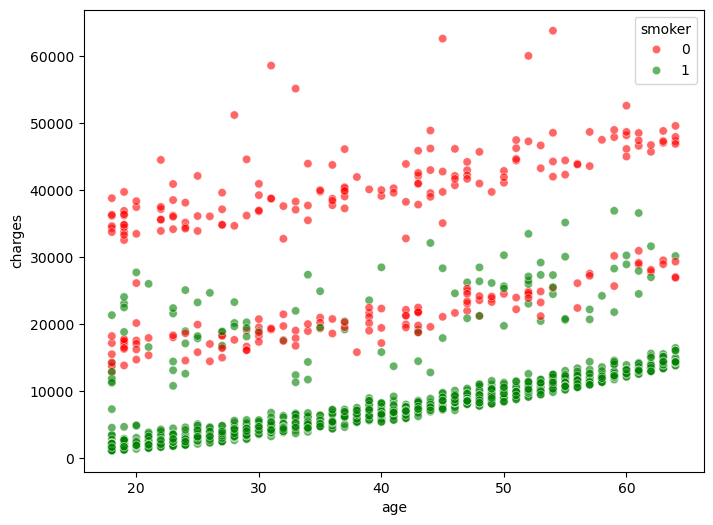

In [63]:
fig, ax = plt.subplots(figsize=(8,6))
# draw a scatter plot
sns.scatterplot(
    data = df,
    x = 'age',
    y = 'charges',
    ax = ax,
    hue= df.smoker,
    palette= ['red','green'],
    alpha=0.6
)


For both smokers and non-smokers, charges tend to increase with age.

Smokers tend to have significantly higher charges compared to non-smokers.

<Axes: >

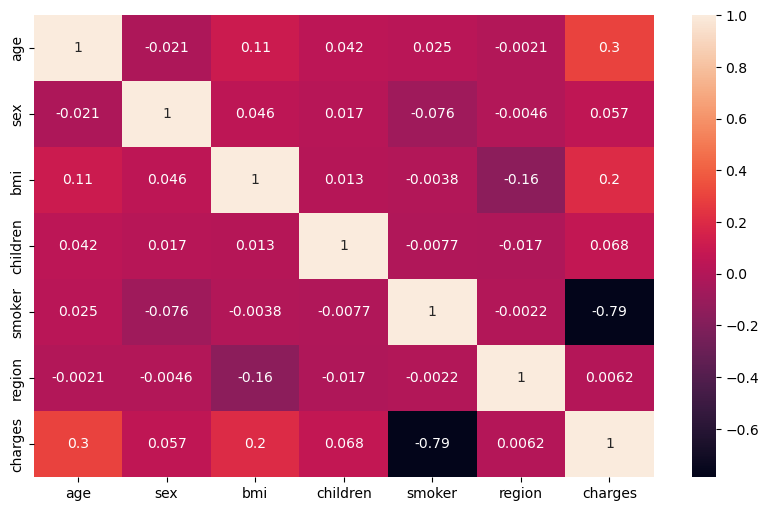

In [65]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr().T, annot=True)

Observations:

Smoker and charges:
"smoker" has a strong negative correlation with "charges," suggesting that being a smoker significantly increases charges.

Age and charges:
There is a moderate positive correlation between "age" and "charges," meaning older individuals are likely to have higher charges.

BMI and charges:
"bmi" has a weak positive correlation with "charges," suggesting higher BMI is slightly associated with increased charges.

Others:
Variables like "sex," "region," and "children" have very weak correlations with "charges," indicating limited influence on the charges.

In [67]:
# Define features and target variable
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

In [68]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [69]:
# Split the data into training and testing sets (20% for testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1: Random Forest

In [71]:
# Initialize the Random Forest Regression model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

In [72]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees (wider range)
    'max_depth': [None, 5, 10],    # Maximum depth of the tree (more options)
    'min_samples_split': [2, 5],       # Minimum samples required to split a node
    'min_samples_leaf': [1, 2],          # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2']  # Number of features for the best split
}

In [73]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Evaluation metric
    verbose=2,             # Show detailed logs
    n_jobs=-1              # Use all CPU cores
)

In [74]:
# Perform grid search
print("Starting grid search...")
grid_search.fit(X_train, y_train)

Starting grid search...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=2)

In [75]:
# Output the best parameter combination
print("\nBest parameter combination:")
print(grid_search.best_params_)


Best parameter combination:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [76]:
# Get the best model
best_rf = grid_search.best_estimator_

In [77]:
# Make predictions using the best model
y_pred = best_rf.predict(X_test)

In [78]:
# Model evaluation function
def evaluate_model(y_true, y_pred):
    """Calculate and return various evaluation metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'R² Score': round(r2, 4)
    }

In [79]:
# Get evaluation results
metrics = evaluate_model(y_test, y_pred)

In [80]:
# Print evaluation results
print("\nOptimized model evaluation results:")
for metric, value in metrics.items():
    print(f"{metric}: {value}")


Optimized model evaluation results:
MSE: 20045377.48
RMSE: 4477.21
MAE: 2700.42
R² Score: 0.8709


In [81]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [82]:
print("\nFeature importance ranking:")
print(feature_importance)


Feature importance ranking:
    Feature  Importance
4    smoker    0.645010
2       bmi    0.156925
0       age    0.146213
3  children    0.023422
5    region    0.019364
1       sex    0.009066


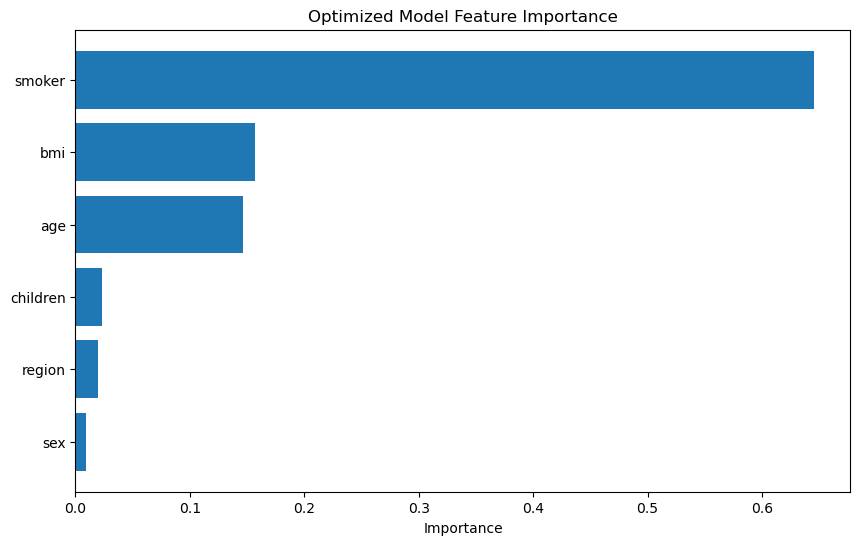

In [83]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Optimized Model Feature Importance')
plt.gca().invert_yaxis()
plt.show()
# Smoker is the most influential predictor of medical charges,accounting for approximately 64.5% of the model's decision-making process.
# The second and third most important features are bmi (15.7%) and age (14.6%).
# The number of children (2.3%), region (1.9%), and sex (0.9%) have relatively minor effects on the predicted charges.

In [84]:
# Save the best model
joblib.dump(best_rf, 'optimized_insurance_rf_model.pkl')
print("\nModel saved as optimized_insurance_rf_model.pkl")


Model saved as optimized_insurance_rf_model.pkl


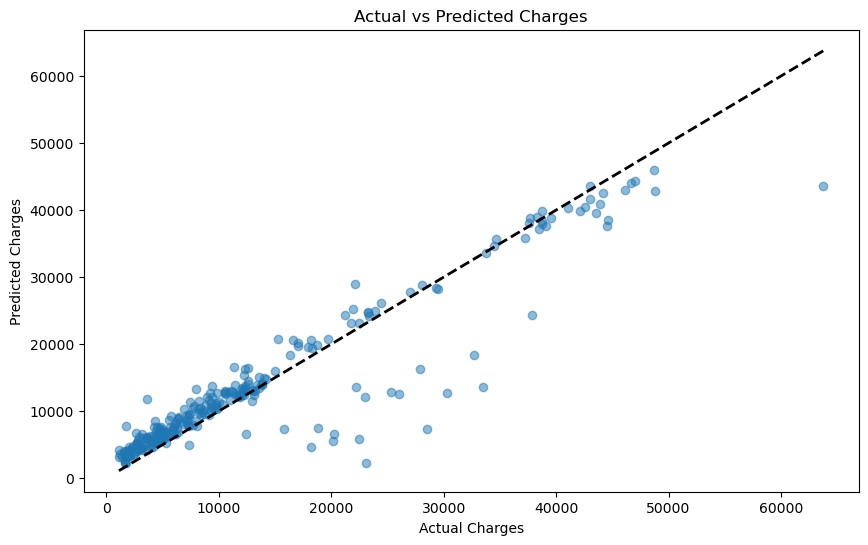

In [85]:
# Add regression analysis visualization
# Create a scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Add a diagonal line
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.show()
# Most of the scatter-points are concentrated near the diagonal dotted line.

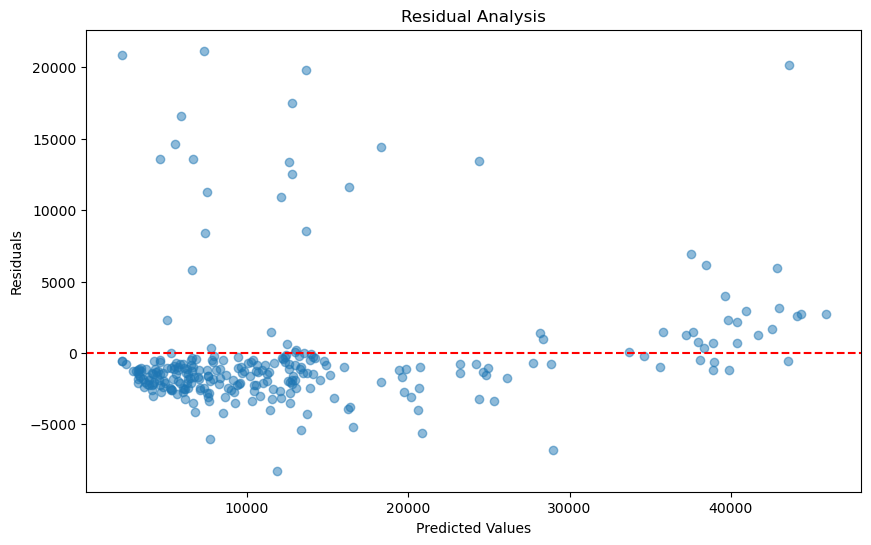

In [86]:
# Residual analysis plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.show()
# Most residuals are concentrated around zero, suggesting that the model performs well within these ranges of predicted values, with predicted and actual values being relatively close.

## Model 2 Ridge

In [88]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [90]:
# Define the preprocessing and modeling pipeline
ridge_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),  # Feature scaling
    ('ridge', Ridge())
])

In [92]:
# Define the parameter grid for Ridge Regression
ridge_param_grid = {
    'ridge__alpha': [0.1, 1, 10, 100, 200, 500, 1000]
}

In [95]:
# Create GridSearchCV object for Ridge Regression
ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Evaluation metric
    verbose=2,  # Show detailed logs
    n_jobs=-1  # Use all CPU cores
)

In [96]:
# Perform grid search
print("Starting Ridge Regression grid search...")
ridge_grid.fit(X_train, y_train)

Starting Ridge Regression grid search...
Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'ridge__alpha': [0.1, 1, 10, 100, 200, 500, 1000]},
             scoring='neg_mean_squared_error', verbose=2)

In [97]:
# Output the best parameter combination
print("\nBest Ridge Regression Parameters:")
print(ridge_grid.best_params_)


Best Ridge Regression Parameters:
{'ridge__alpha': 1}


In [103]:
# Get the best Ridge Regression model
best_ridge = ridge_grid.best_estimator_

In [104]:
# Make predictions using the best Ridge Regression model
y_pred_ridge = best_ridge.predict(X_test)

In [105]:
# Evaluate Ridge Regression model
ridge_metrics = evaluate_model(y_test, y_pred_ridge)

In [106]:
# Print evaluation results
print("\nOptimized model evaluation results:")
for metric, value in ridge_metrics.items():
    print(f"{metric}: {value}")


Optimized model evaluation results:
MSE: 33641818.59
RMSE: 5800.16
MAE: 4187.97
R² Score: 0.7833


In [107]:
# Analyze coefficients
# Extract the Ridge model from the pipeline
ridge_model = best_ridge.named_steps['ridge']

In [108]:
# Get feature names
feature_names = X.columns

In [109]:
# Get the coefficients
coef = ridge_model.coef_

In [110]:
# Create a DataFrame for coefficients
ridge_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
}).sort_values(by='Coefficient', ascending=False)

In [111]:
print("\nRidge Regression Coefficients:")
print(ridge_coefficients)


Ridge Regression Coefficients:
    Feature  Coefficient
0       age  3612.448532
2       bmi  2026.717680
3  children   516.517239
5    region   301.857800
1       sex    -8.730956
4    smoker -9547.984516


/var/folders/xj/t1frh4jx3fdcp7k856wr00j40000gn/T/ipykernel_4304/3182914028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=ridge_coefficients, palette='viridis')


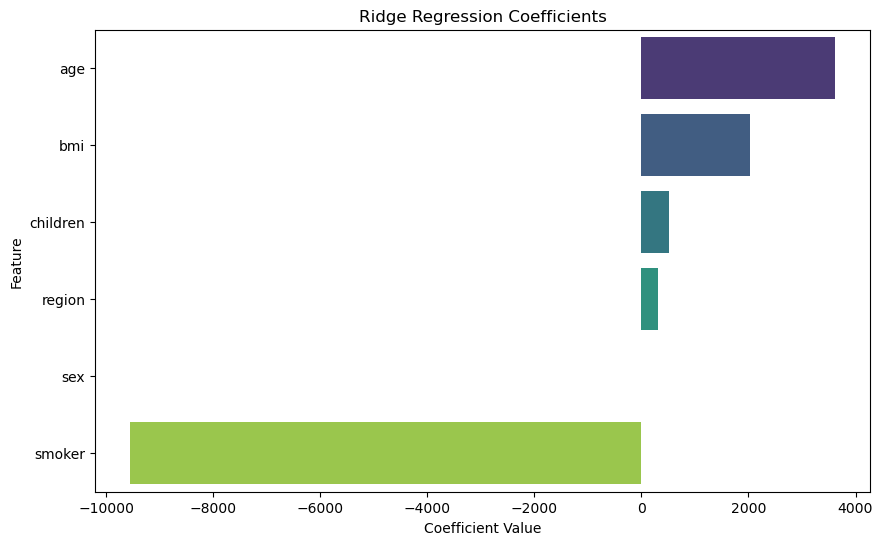

In [112]:
# Visualize coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=ridge_coefficients, palette='viridis')
plt.title('Ridge Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

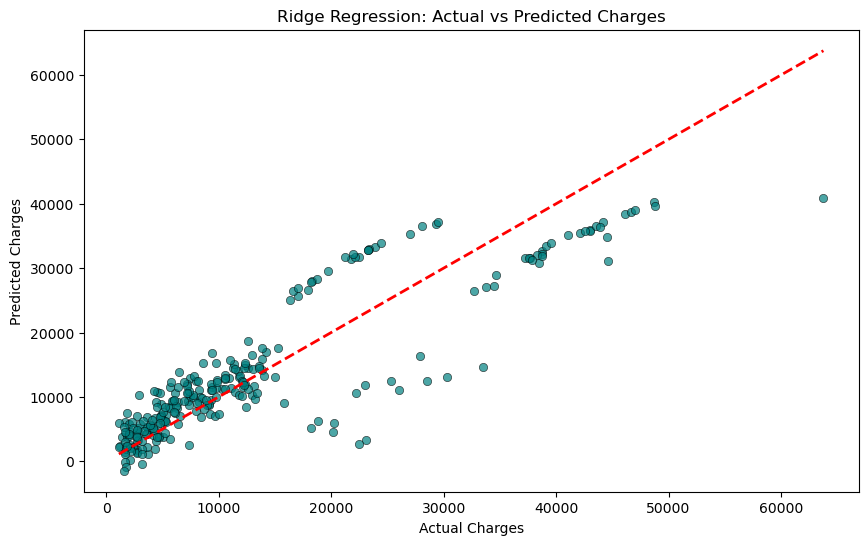

In [113]:
# Scatter plot of actual vs predicted charges for Ridge Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge, color='teal', edgecolor='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Ridge Regression: Actual vs Predicted Charges')
plt.show()

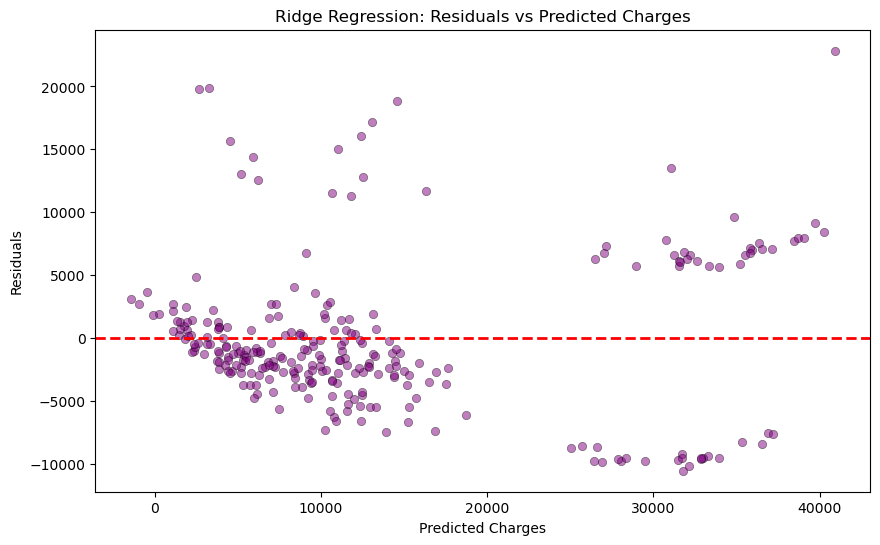

In [114]:
# Residual analysis for Ridge Regression
residuals_ridge = y_test - y_pred_ridge
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge, color='purple', edgecolor='k', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Ridge Regression: Residuals vs Predicted Charges')
plt.show()

## Model 2: LASSO

In [116]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

In [117]:
# generate a group of alpha values
alphas = np.logspace(-4, 1, 100)

# using LassoCV to cross-evaluate
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

# print the best alpha 
print(f"best alpha : {lasso_cv.alpha_}")

best alpha : 10.0


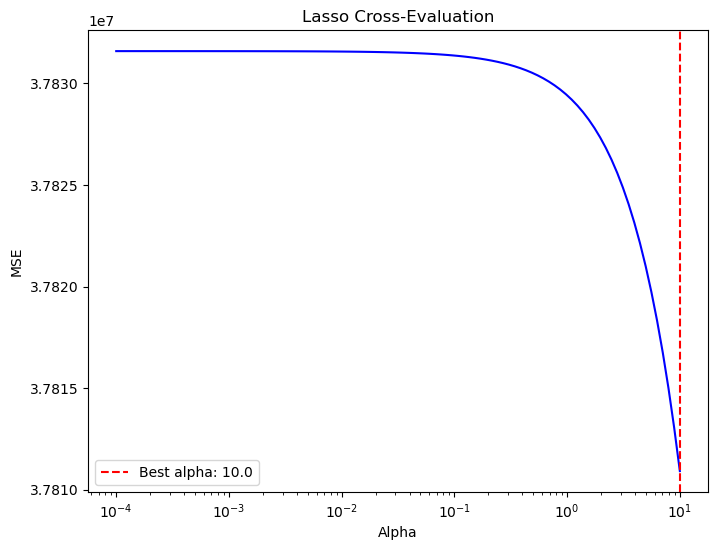

In [118]:
# draw alpha value with score of cross-evaluation
plt.figure(figsize=(8, 6))
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1), 'b-')
plt.axvline(lasso_cv.alpha_, color='r', linestyle='--', label=f'Best alpha: {lasso_cv.alpha_}')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Lasso Cross-Evaluation')
plt.legend()
plt.show()
# For very small alpha values, MSE remains almost unchanged.
# As alpha increases beyond a certain point, MSE starts rising, indicating excessive regularization leading to underfitting.
# The selected alpha (10.0) is chosen to balance bias and variance, preventing overfitting while ensuring a reasonable error rate.

In [119]:
# using best alpha to train LASSO model
lasso_model = Lasso(alpha=lasso_cv.alpha_)
lasso_model.fit(X_train, y_train)

# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# predict on test dataset
y_pred = lasso_model.predict(X_test)

# Get evaluation results
metrics = evaluate_model(y_test, y_pred)

# Print evaluation results
print("\nOptimized model evaluation results:")
for metric, value in metrics.items():
    print(f"{metric}: {value}")


Optimized model evaluation results:
MSE: 33669881.76
RMSE: 5802.58
MAE: 4192.78
R² Score: 0.7831


In [120]:
# get coefficients
coefficients = lasso_model.coef_

# match the features and  coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# order by coefficients
feature_importance = feature_importance.reindex(
    feature_importance['Coefficient'].abs().sort_values(ascending=False).index
)

print("feature importance:")
print(feature_importance)

feature importance:
    Feature   Coefficient
4    smoker -23585.265190
3  children    418.605736
2       bmi    335.231375
5    region    262.887369
0       age    256.968841
1       sex     -0.000000


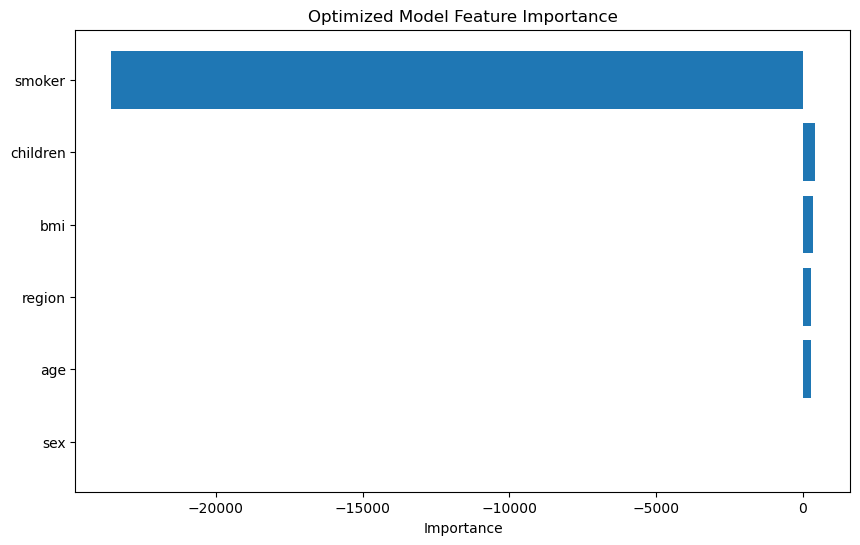

In [170]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Importance')
plt.title('Optimized Model Feature Importance')
plt.gca().invert_yaxis()
plt.show()
# "Smoker" has the strongest negative impact, indicating it is the most influential factor in predicting medical costs.
# Other features have minimal impact, suggesting the model relies primarily on the "smoker" variable.
# All coefficients are negative, likely due to Lasso regularization shrinking less significant features toward zero.

['optimized_lasso_model.pkl']

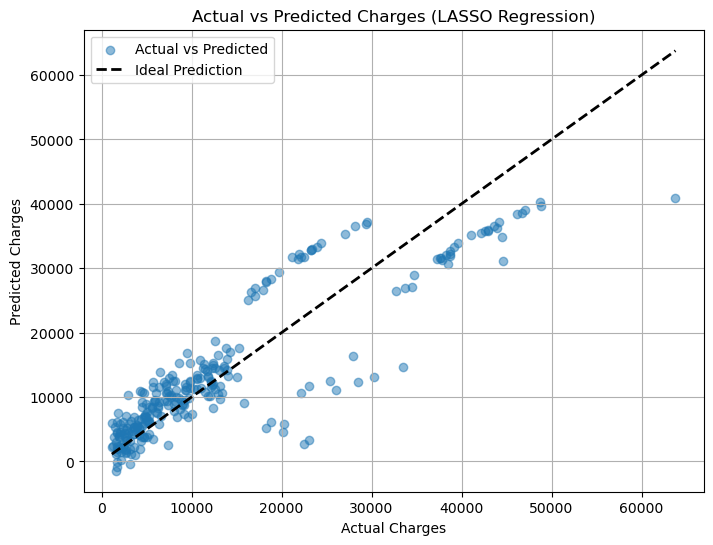

In [123]:
# draw scatter figure
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Actual vs Predicted')

# Add diagonal line (ideally predicted value = actual value)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Prediction')

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (LASSO Regression)')
plt.legend()
plt.grid(True)
plt.show()
# General Fit: The predicted charges generally align with actual charges, forming a pattern close to the ideal diagonal line.
# Underestimation at High Values: The model tends to underestimate higher actual charges, as many points fall below the dashed line.
# Better Accuracy at Lower Charges: Predictions are more tightly clustered around the ideal line for lower actual charges, suggesting better performance in that range.
# Higher Variability at Higher Charges: The spread increases as actual charges rise, indicating that the model struggles with high-cost predictions.

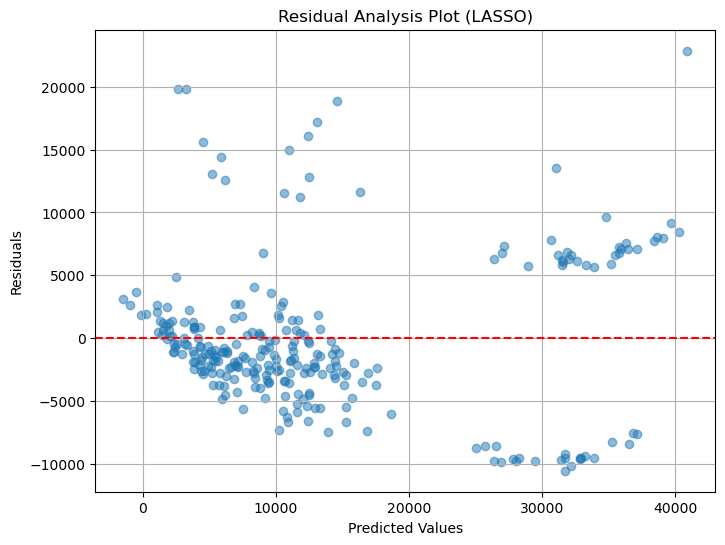

In [124]:
residuals = y_test - y_pred  # residuals computaion

# draw Residual Analysis Plot for LASSO
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')  # horizontal line
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis Plot (LASSO)')
plt.grid(True)
plt.show()
# The red dashed line at y=0 indicates the ideal scenario where the model perfectly predicts all observations.
# A cluster of negative residuals is observed for lower predicted values (0 to 10,000), suggesting the model underestimates costs in this range.
# As predicted values increase, residuals trend positively, indicating potential overestimation of costs for higher predicted values (around 30,000 and above).
# The spread of residuals varies across predicted values, indicating potential heteroscedasticity where variance is not constant.
# The transparency of the points enhances visibility and helps identify areas of high density in the plot.